## Parte 1 - Conectividade

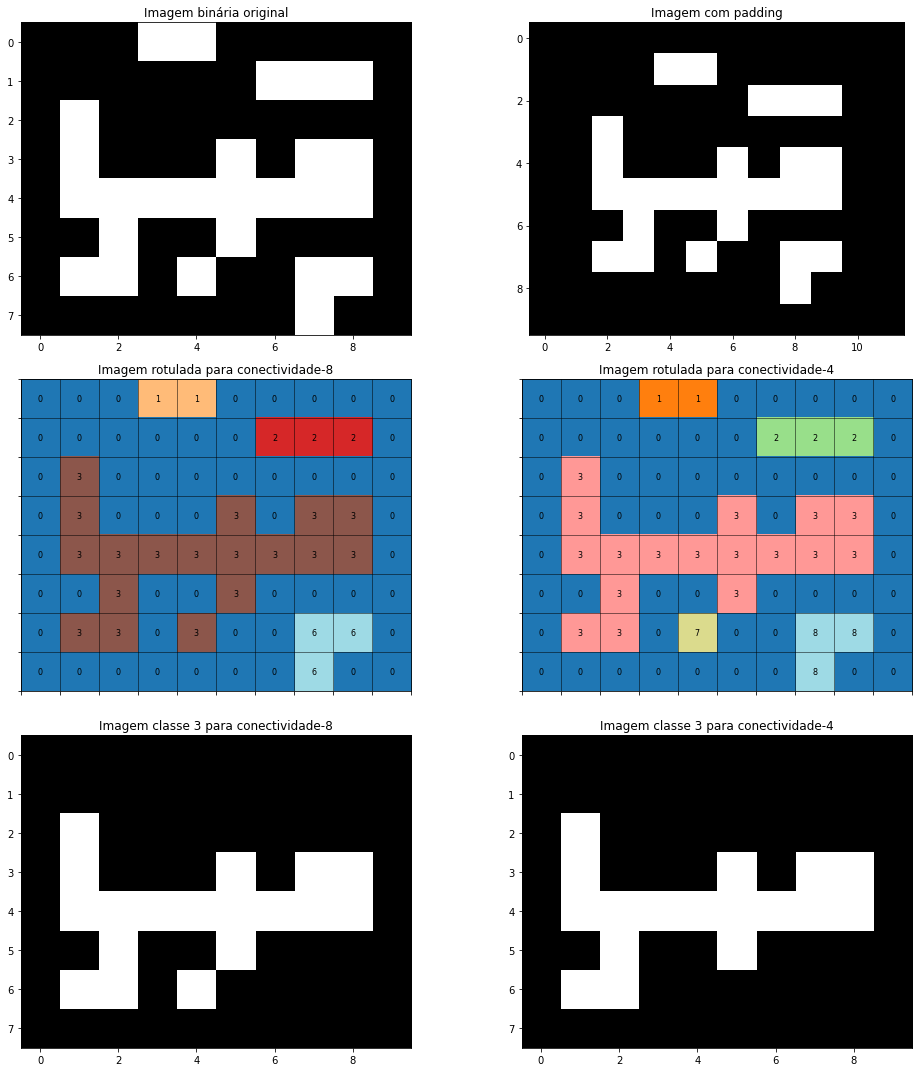

In [77]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def label_conectados_8(imagem_binaria):
    imagem_pad = np.pad(imagem_binaria, pad_width=1, mode='constant', constant_values=0)
    labels = np.zeros_like(imagem_pad, dtype=int)
    label = 1
    equivalente = {}

    for i in range(1, imagem_pad.shape[0] - 1): # passagem 1
        for j in range(1, imagem_pad.shape[1] - 1):
            if imagem_pad[i, j] == 1:
                vizinhos = [
                    labels[i-1, j-1], labels[i-1, j], labels[i-1, j+1], labels[i, j-1]
                ]
                vizinho_1 = [n for n in vizinhos if n > 0]

                if not vizinho_1:
                    labels[i, j] = label
                    equivalente[label] = {label}
                    label += 1
                else:
                    min_label = min(vizinho_1)
                    labels[i, j] = min_label
                    for vizinho_label in vizinho_1:
                        equivalente[min_label].update(equivalente[vizinho_label])
                        equivalente[vizinho_label] = equivalente[min_label]

    for i in range(1, labels.shape[0] - 1): # passagem 2
        for j in range(1, labels.shape[1] - 1):
            if labels[i, j] > 0:
                labels[i, j] = min(equivalente[labels[i, j]])

    return labels[1:-1, 1:-1], imagem_pad

def label_conectados_4(imagem_binaria):
    imagem_pad = np.pad(imagem_binaria, pad_width=1, mode='constant', constant_values=0)
    labels = np.zeros_like(imagem_pad, dtype=int)
    label = 1
    equivalente = {}

    for i in range(1, imagem_pad.shape[0] - 1):  # passagem 1
        for j in range(1, imagem_pad.shape[1] - 1):
            if imagem_pad[i, j] == 1:
                vizinhos = [labels[i-1, j], labels[i, j-1]]
                vizinho_1 = [n for n in vizinhos if n > 0]

                if not vizinho_1:
                    labels[i, j] = label
                    equivalente[label] = {label}
                    label += 1
                else:
                    min_label = min(vizinho_1)
                    labels[i, j] = min_label
                    for vizinho_label in vizinho_1:
                        equivalente[min_label].update(equivalente[vizinho_label])
                        equivalente[vizinho_label] = equivalente[min_label]

    for i in range(1, labels.shape[0] - 1):  # Passagem 2
        for j in range(1, labels.shape[1] - 1):
            if labels[i, j] > 0:
                labels[i, j] = min(equivalente[labels[i, j]])

    return labels[1:-1, 1:-1], imagem_pad

def classe_(imagem_label, classe_label):
    classe_image = np.zeros_like(imagem_label)
    classe_image[imagem_label == classe_label] = 1
    return classe_image

imagem_binaria = np.array([
    [0, 0, 0, 1, 1, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 1, 1, 1, 0],
    [0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 0, 0, 0, 1, 0, 1, 1, 0],
    [0, 1, 1, 1, 1, 1, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 1, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 0, 0, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 1, 0, 0]
])

imagem_label_8, imagem_pad_8 = label_conectados_8(imagem_binaria)
imagem_label_4, imagem_pad_4 = label_conectados_4(imagem_binaria)

classe_3_lab8 = classe_(imagem_label_8, 3)
classe_3_lab4 = classe_(imagem_label_4, 3)

fig, ax = plt.subplots(3, 2, figsize=(15, 15))

ax[0, 0].imshow(imagem_binaria, cmap='gray')
ax[0, 0].set_title('Imagem binária original')
ax[0, 0].axis('on')

ax[0, 1].imshow(imagem_pad, cmap='gray')
ax[0, 1].set_title('Imagem com padding')
ax[0, 1].axis('on')

ax[0, 1].imshow(imagem_pad_8, cmap='gray')
ax[0, 1].set_title('Imagem com padding')
ax[0, 1].axis('on')

ax[1, 0].imshow(imagem_label_8, cmap='tab20')
for i in range(imagem_label_8.shape[0]):
    for j in range(imagem_label_8.shape[1]):
        label = imagem_label_8[i, j]
        ax[1, 0].text(j, i, label, ha='center', va='center', color='black', fontsize=8)
ax[1, 0].set_xticks(np.arange(-0.5, imagem_label_8.shape[1], 1))
ax[1, 0].set_yticks(np.arange(-0.5, imagem_label_8.shape[0], 1))
ax[1, 0].grid(which='both', color='black', linestyle='-', linewidth=0.5)
ax[1, 0].set_xticklabels([])
ax[1, 0].set_yticklabels([])
ax[1, 0].set_title('Imagem rotulada para conectividade-8')

ax[1, 1].imshow(imagem_label_4, cmap='tab20')
for i in range(imagem_label_4.shape[0]):
    for j in range(imagem_label_4.shape[1]):
        label = imagem_label_4[i, j]
        ax[1, 1].text(j, i, label, ha='center', va='center', color='black', fontsize=8)
ax[1, 1].set_xticks(np.arange(-0.5, imagem_label_4.shape[1], 1))
ax[1, 1].set_yticks(np.arange(-0.5, imagem_label_4.shape[0], 1))
ax[1, 1].grid(which='both', color='black', linestyle='-', linewidth=0.5)
ax[1, 1].set_xticklabels([])
ax[1, 1].set_yticklabels([])
ax[1, 1].set_title('Imagem rotulada para conectividade-4')

ax[2, 0].imshow(classe_3_lab8, cmap='gray')
ax[2, 0].set_title('Imagem classe 3 para conectividade-8')
ax[2, 0].axis('on')

ax[2, 1].imshow(classe_3_lab4, cmap='gray')
ax[2, 1].set_title('Imagem classe 3 para conectividade-4')
ax[2, 1].axis('on')

plt.tight_layout()
plt.show()

### Máscara da conectividade-4 para explicação

<div style="display: flex; justify-content: space-around;">
    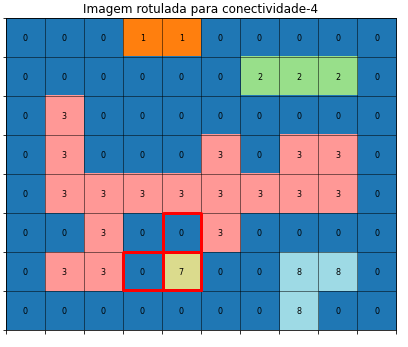
    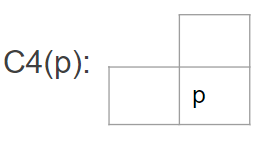
</div>

### Máscara da conectividade-8 para explicação

<div style="display: flex; justify-content: space-around;">
    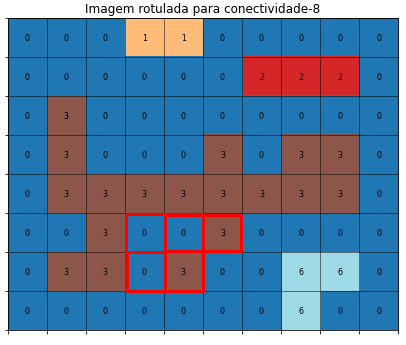
    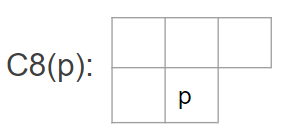
</div>

## Parte 2 - Bounding Image

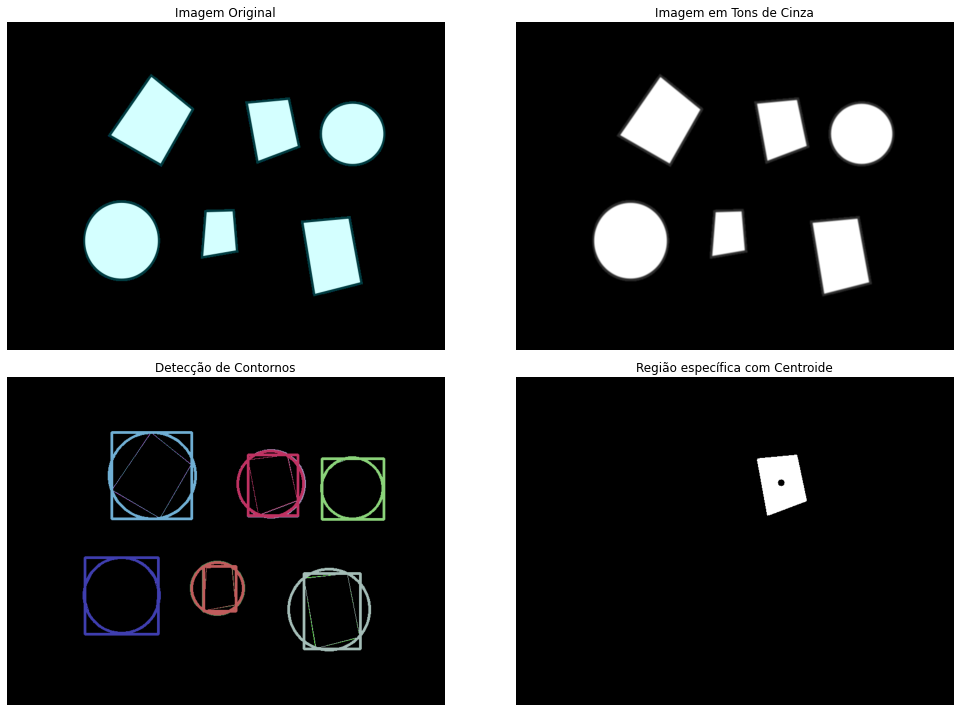

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

def callback(val):
    threshold = val
    canny_output = cv.Canny(src_gray, threshold, threshold * 2)
    contornos, _ = cv.findContours(canny_output, cv.RETR_TREE, cv.CHAIN_APPROX_SIMPLE)
    
    aprox_poligonais = [None] * len(contornos)
    retangulos = [None] * len(contornos)
    centros = [None] * len(contornos)
    raios = [None] * len(contornos)
    
    for i, c in enumerate(contornos):
        aprox_poligonais[i] = cv.approxPolyDP(c, 3, True)
        retangulos[i] = cv.boundingRect(aprox_poligonais[i])
        centros[i], raios[i] = cv.minEnclosingCircle(aprox_poligonais[i])
    
    img_branco = np.zeros((canny_output.shape[0], canny_output.shape[1], 3), dtype=np.uint8)
    
    for i in range(len(contornos)):
        color = (np.random.randint(0, 256), np.random.randint(0, 256), np.random.randint(0, 256))
        cv.drawContours(img_branco, aprox_poligonais, i, color)
        cv.rectangle(img_branco, (int(retangulos[i][0]), int(retangulos[i][1])),
                     (int(retangulos[i][0] + retangulos[i][2]), int(retangulos[i][1] + retangulos[i][3])), color, 3)
        cv.circle(img_branco, (int(centros[i][0]), int(centros[i][1])), int(raios[i]), color, 3)
    
    return img_branco, contornos

src = cv.imread('teste1.png')
if src is None:
    print('Could not open or find the image')
    exit(1)
else:
    src_gray = cv.cvtColor(src, cv.COLOR_BGR2GRAY)
    src_gray = cv.blur(src_gray, (3, 3)) # desfoque gaussiano
    limiar = 100
    max_limiar = 255

    result, contornos = callback(limiar)

    if len(contornos) >= 3:
        contorno_8 = np.zeros_like(src_gray)
        cv.drawContours(contorno_8, [contornos[8]], -1, (255, 255, 255), thickness=cv.FILLED)
        moments = cv.moments(contornos[8])
        if moments['m00'] != 0:
            cx = int(moments['m10'] / moments['m00'])
            cy = int(moments['m01'] / moments['m00'])
            cv.circle(contorno_8, (cx, cy), 6, (0, 255, 0), -1)
    else:
        contorno_8 = np.zeros_like(src_gray)

    plt.figure(figsize=(15, 10))

    plt.subplot(2, 2, 1)
    plt.imshow(cv.cvtColor(src, cv.COLOR_BGR2RGB))
    plt.title('Imagem Original')
    plt.axis('off')

    plt.subplot(2, 2, 2)
    plt.imshow(src_gray, cmap='gray')
    plt.title('Imagem em Tons de Cinza')
    plt.axis('off')

    plt.subplot(2, 2, 3)
    plt.imshow(cv.cvtColor(result, cv.COLOR_BGR2RGB))
    plt.title('Detecção de Contornos')
    plt.axis('off')

    plt.subplot(2, 2, 4)
    plt.imshow(contorno_8, cmap='gray')
    plt.title('Região específica com Centroide')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

In [71]:
pip install opencv-python


Note: you may need to restart the kernel to use updated packages.
